In [3]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

sys.path.append('..')
file_path = '../data/processed/notebooks/master_analytical_file.parquet'

if os.path.exists(file_path):
    df_master = pd.read_parquet(file_path)
    print(f"Loaded Master Data: {len(df_master):,} rows")
    print(f"Date range: {df_master['shipped_dt'].min()} to {df_master['shipped_dt'].max()}")
else:
    print("Error: Master file not found. Please run Notebook 02 first.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded Master Data: 1,983,549 rows
Date range: 2025-01-01 00:00:00.275000 to 2025-12-31 21:40:11


In [4]:
#Sample to Sale Conversion
funnel_data = df_master.groupby('type')['trade_account_id'].nunique().reset_index()
funnel_data = funnel_data.sort_values('trade_account_id', ascending=False)

fig = px.funnel(
    funnel_data, 
    x='trade_account_id', 
    y='type',
    title='Customer Journey: Sample to Sale Conversion',
    color_discrete_sequence=['#2C3E50', '#E67E22'], 
    labels={'trade_account_id': 'Unique Customers', 'type': 'Stage'}
)

fig.update_traces(textinfo="value+percent initial")
fig.show()

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\2667252226.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  funnel_data = df_master.groupby('type')['trade_account_id'].nunique().reset_index()


In [5]:
#Same Item Sampled vs Sold
sample_pairs = df_master[df_master['type'] == 'SAMPLE'][['trade_account_id', 'item_number']].drop_duplicates()
sale_pairs = df_master[df_master['type'] == 'SALE'][['trade_account_id', 'item_number']].drop_duplicates()
matched_pairs = pd.merge(sample_pairs, sale_pairs, on=['trade_account_id', 'item_number'], how='inner')

matched_funnel_data = pd.DataFrame({
    'Stage': ['Unique Items Sampled', 'Matched Items Sold'],
    'Count': [len(sample_pairs), len(matched_pairs)]
})

fig_matched = px.funnel(
    matched_funnel_data, 
    x='Count', 
    y='Stage',
    title='Product-Level Conversion: Same Item Sampled vs Sold',
    color_discrete_sequence=['#34495E', '#D4AC0D']
)
fig_matched.update_traces(textinfo="value+percent initial")
fig_matched.show()

Average Samples to first Sale: 37.17


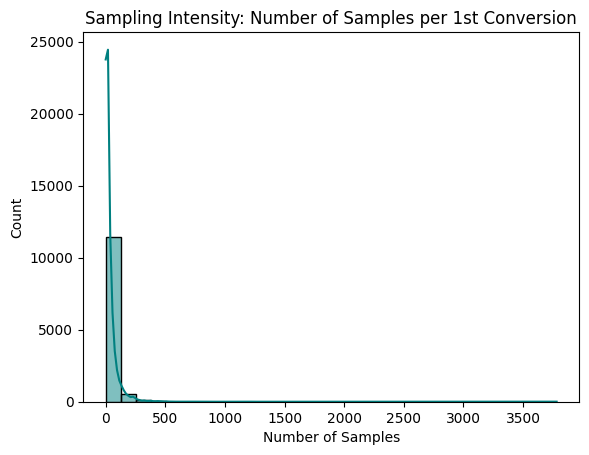

In [6]:
# Sampling Intensity
first_sale = df_master[df_master['type'] == 'SALE'].groupby('trade_account_id')['shipped_dt'].min().reset_index()
first_sale.columns = ['trade_account_id', 'first_sale_date']

pre_sale_samples = df_master[df_master['type'] == 'SAMPLE'].merge(first_sale, on='trade_account_id', how='left')
pre_sale_samples = pre_sale_samples[pre_sale_samples['shipped_dt'] < pre_sale_samples['first_sale_date']]

sampling_intensity = pre_sale_samples.groupby('trade_account_id').size()

print(f"Average Samples to first Sale: {sampling_intensity.mean():.2f}")
sns.histplot(sampling_intensity, bins=30, kde=True, color='teal')
plt.title('Sampling Intensity: Number of Samples per 1st Conversion')
plt.xlabel('Number of Samples')
plt.show()

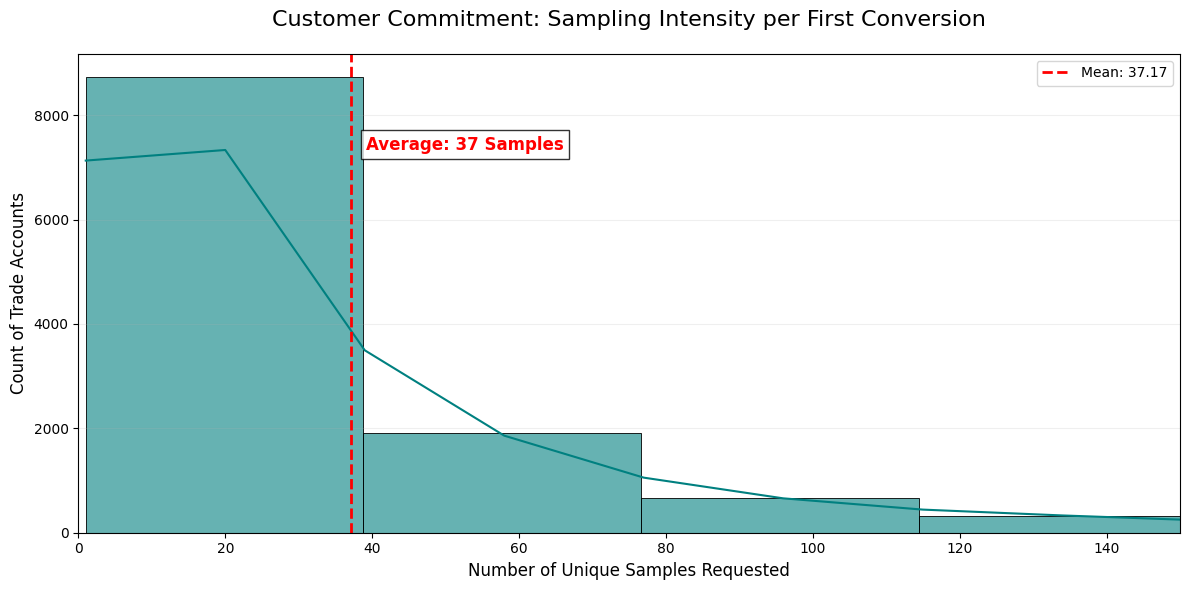

In [7]:
first_sale = df_master[df_master['type'] == 'SALE'].groupby('trade_account_id')['shipped_dt'].min().reset_index()
first_sale.columns = ['trade_account_id', 'first_sale_date']

pre_sale_samples = df_master[df_master['type'] == 'SAMPLE'].merge(first_sale, on='trade_account_id', how='left')
pre_sale_samples = pre_sale_samples[pre_sale_samples['shipped_dt'] < pre_sale_samples['first_sale_date']]

sampling_intensity = pre_sale_samples.groupby('trade_account_id').size()
avg_val = sampling_intensity.mean()

plt.figure(figsize=(12, 6))
sns.histplot(sampling_intensity, bins=100, kde=True, color='#008080', alpha=0.6)

plt.axvline(avg_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_val:.2f}')

plt.text(avg_val + 2, plt.ylim()[1] * 0.8, f'Average: {int(avg_val)} Samples', 
        color='red', fontweight='bold', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.xlim(0, 150) 
plt.title('Customer Commitment: Sampling Intensity per First Conversion', fontsize=16, pad=20)
plt.xlabel('Number of Unique Samples Requested', fontsize=12)
plt.ylabel('Count of Trade Accounts', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\3983117531.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




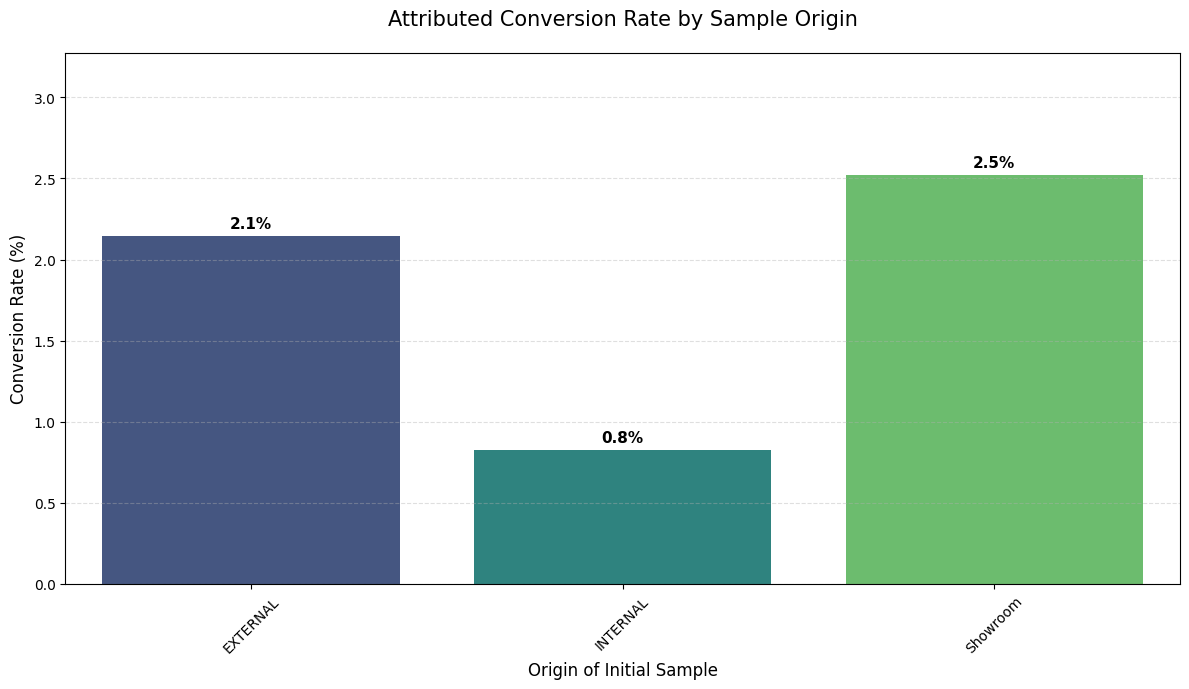

In [8]:
# Conversion Efficiency by Origin
samples = df_master[df_master['type'] == 'SAMPLE'].groupby(['trade_account_id', 'item_number'])['shipped_dt'].min().reset_index()
samples.columns = ['trade_account_id', 'item_number', 'sample_date']

sales = df_master[df_master['type'] == 'SALE'].groupby(['trade_account_id', 'item_number'])['shipped_dt'].min().reset_index()
sales.columns = ['trade_account_id', 'item_number', 'sale_date']

funnel_df = pd.merge(samples, sales, on=['trade_account_id', 'item_number'], how='inner')

funnel_df = funnel_df[funnel_df['sale_date'] >= funnel_df['sample_date']]
funnel_df['days_to_convert'] = (funnel_df['sale_date'] - funnel_df['sample_date']).dt.days

sample_origins = df_master[df_master['type'] == 'SAMPLE'][['trade_account_id', 'item_number', 'origin']].drop_duplicates()

matched_journeys = funnel_df.merge(sample_origins, on=['trade_account_id', 'item_number'], how='left')

total_samples_per_origin = sample_origins['origin'].value_counts()
successful_sales_per_origin = matched_journeys['origin'].value_counts()

origin_stats = pd.DataFrame({
    'SAMPLE': total_samples_per_origin,
    'SALE': successful_sales_per_origin
}).fillna(0)

origin_stats['conversion_rate'] = (origin_stats['SALE'] / origin_stats['SAMPLE']) * 100
origin_stats = origin_stats.sort_values('conversion_rate', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=origin_stats.index, y=origin_stats['conversion_rate'], palette='viridis')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Attributed Conversion Rate by Sample Origin', fontsize=15, pad=20)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xlabel('Origin of Initial Sample', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, origin_stats['conversion_rate'].max() * 1.3)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\2597726914.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\2597726914.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




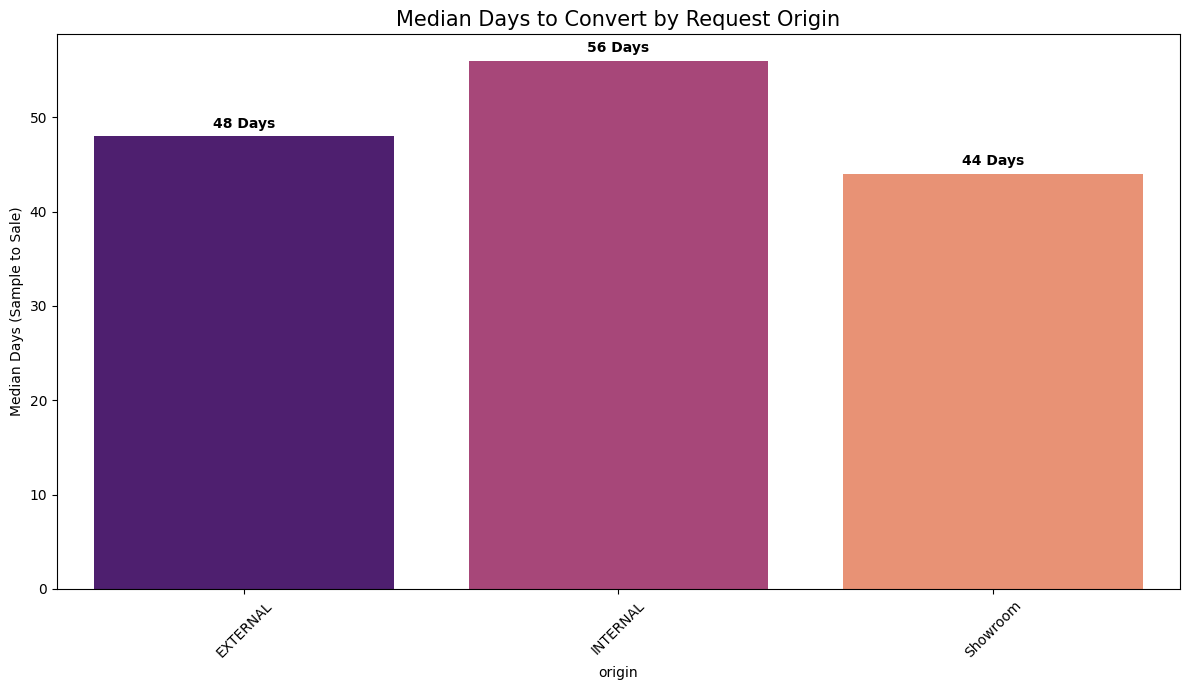

In [9]:
#Days from Sample to Sale by Origin
origin_map = df_master[df_master['type'] == 'SAMPLE'].drop_duplicates(['trade_account_id', 'item_number'])[['trade_account_id', 'item_number', 'origin']]
velocity_df = funnel_df.merge(origin_map, on=['trade_account_id', 'item_number'], how='left')

origin_velocity = velocity_df.groupby('origin')['days_to_convert'].median().sort_values().reset_index()


plt.figure(figsize=(12, 7))
ax = sns.barplot(x='origin', y='days_to_convert', data=origin_velocity, palette='magma')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)} Days', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.title('Median Days to Convert by Request Origin', fontsize=15)
plt.ylabel('Median Days (Sample to Sale)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total Samplers: 25,648
Total 'Ghost' Accounts (Sample but never Buy): 9,476
Ghost Rate: 36.95%


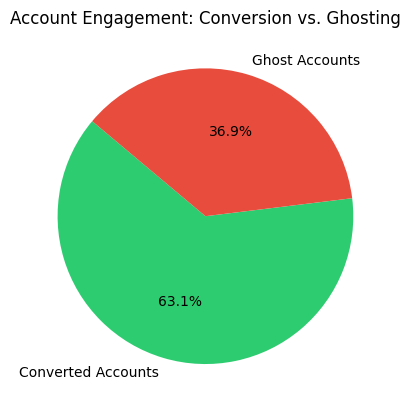

In [10]:
# Identifying Ghosts Accounts
all_samplers = set(df_master[df_master['type'] == 'SAMPLE']['trade_account_id'].unique())
all_buyers = set(df_master[df_master['type'] == 'SALE']['trade_account_id'].unique())

ghosts = all_samplers - all_buyers
ghost_rate = (len(ghosts) / len(all_samplers)) * 100

print(f"Total Samplers: {len(all_samplers):,}")
print(f"Total 'Ghost' Accounts (Sample but never Buy): {len(ghosts):,}")
print(f"Ghost Rate: {ghost_rate:.2f}%")

plt.pie([len(all_samplers)-len(ghosts), len(ghosts)], 
        labels=['Converted Accounts', 'Ghost Accounts'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=140)
plt.title('Account Engagement: Conversion vs. Ghosting')
plt.show()

In [17]:
df_master.head()

,id,order_id,trade_account_id,item_number,shipped_dt,origin,type,netrevenue,quantity,year,...,region,price_usd,arrival_date,category_name,color_name,classification,subclass,scale,color_family,motif
0,9974157,1303020,635887,5008210,2025-01-16 12:21:00.000,EXTERNAL,SAMPLE,0.0,1.0,2025,...,HEARTLAND,94.0,2016-09-05,WALLCOVERINGS,FOG,TEXTURE,PRINT,EXTRA LARGE,LIGHT NEUTRAL,PAISLEY
1,11033952,1420308,647987,5013651,2025-05-01 17:43:00.000,EXTERNAL,SAMPLE,0.0,2.0,2025,...,MIDWEST,48.0,2022-03-07,WALLCOVERINGS,OFF BLACK,FLAT PAPER,PRINT,MEDIUM,LIGHT NEUTRAL,DOTS
2,10381241,1346080,653558,75683,2025-02-21 00:26:06.730,Showroom,SAMPLE,0.0,1.0,2025,...,PACIFIC SOUTHWEST,118.0,2021-08-02,FABRICS,YELLOW,WOVEN,PLAIN WOVEN,SOLID,YELLOW,SOLID
3,9966140,1302139,689951,175160,2025-01-14 14:18:00.000,EXTERNAL,SAMPLE,0.0,1.0,2025,...,SOUTH,178.0,2012-08-15,FABRICS,TAN,PRINT,PRINTED,LARGE,LIGHT NEUTRAL,ANIMAL
4,11123734,1430077,725247,5010571,2025-05-12 12:45:41.000,EXTERNAL,SALE,1160.0,20.0,2025,...,ROCKY MOUNTAINS,58.0,2020-02-03,WALLCOVERINGS,SMOKE,FLAT PAPER,PRINT,LARGE,LIGHT NEUTRAL,GEOMETRIC


In [21]:
all_regions = df_master['region'].unique().tolist()
print(all_regions)

['HEARTLAND', 'MIDWEST', 'PACIFIC SOUTHWEST', 'SOUTH', 'ROCKY MOUNTAINS', 'CAROLINAS', 'MID-ATLANTIC', 'FLORIDIAN PENINSULA', 'TRI-STATE AREA', 'GULF COAST', 'NORTHERN WEST COAST', 'CENTRAL US', 'NEW ENGLAND', 'GREAT LAKES', 'SOUTHWEST', 'CLOSED']


In [ ]:
territory_map = {
    'TRI-STATE AREA': 'NY', 'FLORIDIAN PENINSULA': 'FL', 'NEW ENGLAND': 'MA',
    'MID-ATLANTIC': 'PA', 'GREAT LAKES': 'MI', 'MIDWEST': 'IL',
    'CAROLINAS': 'NC', 'SOUTH': 'GA', 'GULF COAST': 'LA',
    'HEARTLAND': 'KS', 'ROCKY MOUNTAINS': 'CO', 'SOUTHWEST': 'TX',
    'PACIFIC SOUTHWEST': 'AZ', 'NORTHERN WEST COAST': 'WA', 'CENTRAL US': 'MO'
}

regional_perf = df_master.groupby('region').agg(
    total_samples=('type', lambda x: (x == 'SAMPLE').sum()),
    total_sales=('type', lambda x: (x == 'SALE').sum()),
    revenue=('netrevenue', 'sum')
).reset_index()

regional_perf['conv_rate'] = (regional_perf['total_sales'] / regional_perf['total_samples'].replace(0, 1)) * 100
regional_perf['state_code'] = regional_perf['region'].map(territory_map)

fig = px.choropleth(
    regional_perf.dropna(subset=['state_code']),
    locations="state_code",
    locationmode="USA-states",
    color="conv_rate",
    scope="usa",
    hover_name="region",
    hover_data={'total_samples': True, 'total_sales': True, 'conv_rate': ':.2f}%'},
    title="<b>Regional Conversion Velocity: Sample to Sale Efficiency</b>",
    color_continuous_scale="RdYlGn"
)
fig.show()

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\2502101094.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\3811057977.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



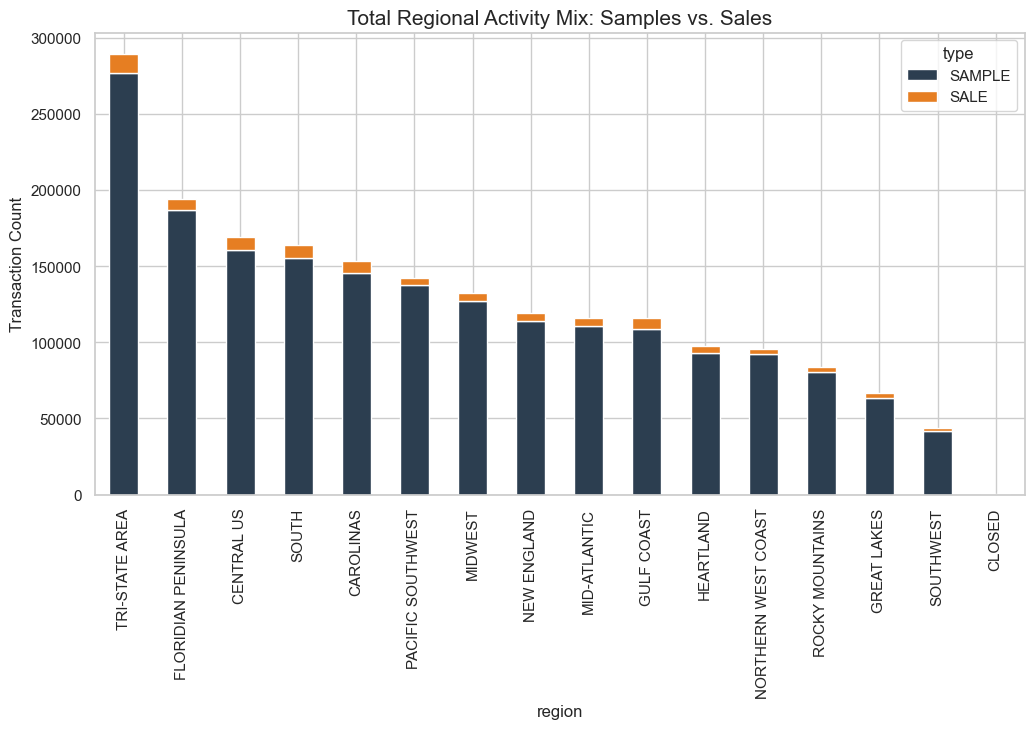

In [23]:
activity_mix = df_master.groupby(['region', 'type']).size().unstack().fillna(0)
activity_mix['Total'] = activity_mix['SAMPLE'] + activity_mix['SALE']
activity_mix = activity_mix.sort_values('Total', ascending=False)

# Visualization
activity_mix[['SAMPLE', 'SALE']].plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2c3e50', '#e67e22'])
plt.title('Total Regional Activity Mix: Samples vs. Sales', fontsize=15)
plt.ylabel('Transaction Count')
plt.show()

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\1917791073.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\1917791073.py:1: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\1917791073.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




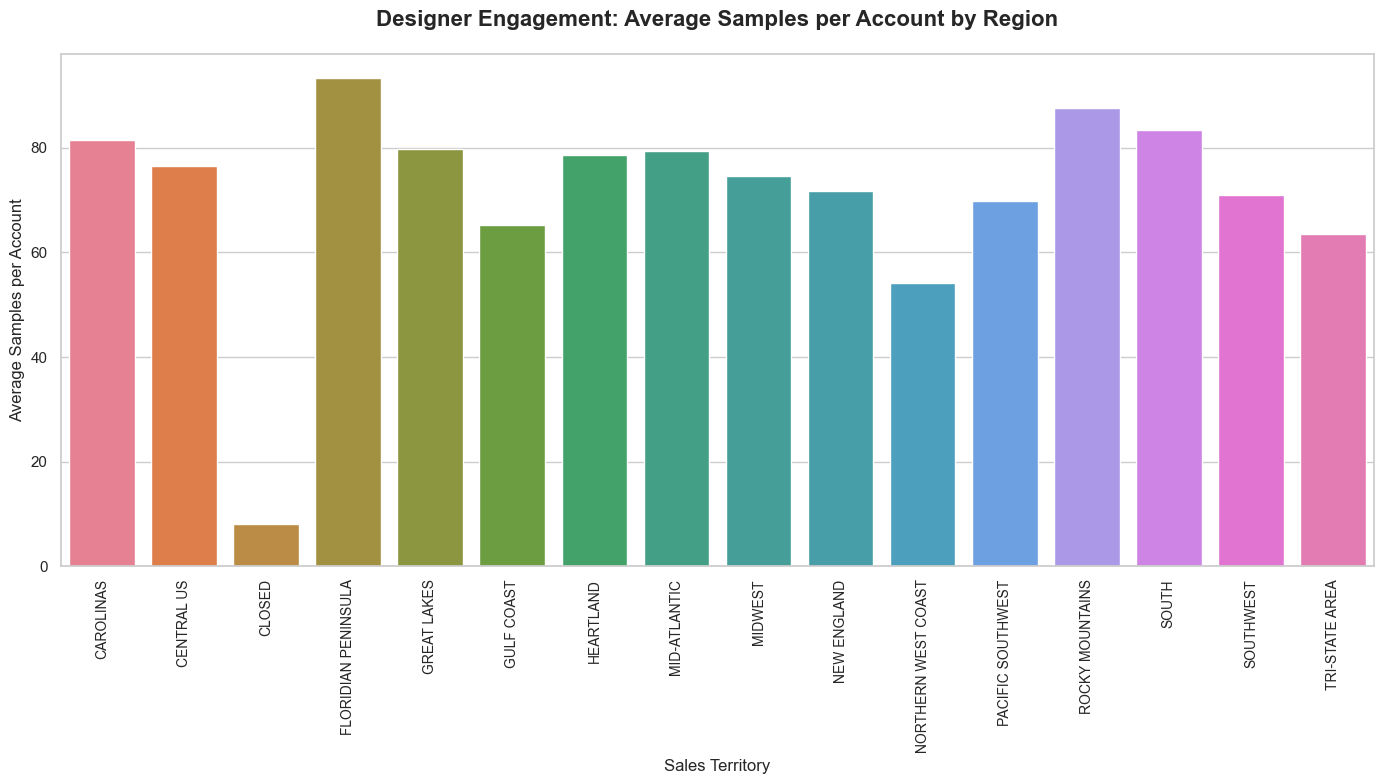

In [ ]:
sampling_intensity = df_master[df_master['type'] == 'SAMPLE'].groupby('region').apply(
    lambda x: x.shape[0] / x['trade_account_id'].nunique()
).sort_values(ascending=False).reset_index(name='Avg_Samples_Per_Account')

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.barplot(
    x='region', 
    y='Avg_Samples_Per_Account', 
    data=sampling_intensity, 
    palette='husl'
)

plt.title('Designer Engagement: Average Samples per Account by Region', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Average Samples per Account', fontsize=12)
plt.xlabel('Sales Territory', fontsize=12)
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.tight_layout() 
plt.show()

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\2419550135.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\P.Avinash\AppData\Local\Temp\ipykernel_13528\2419550135.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



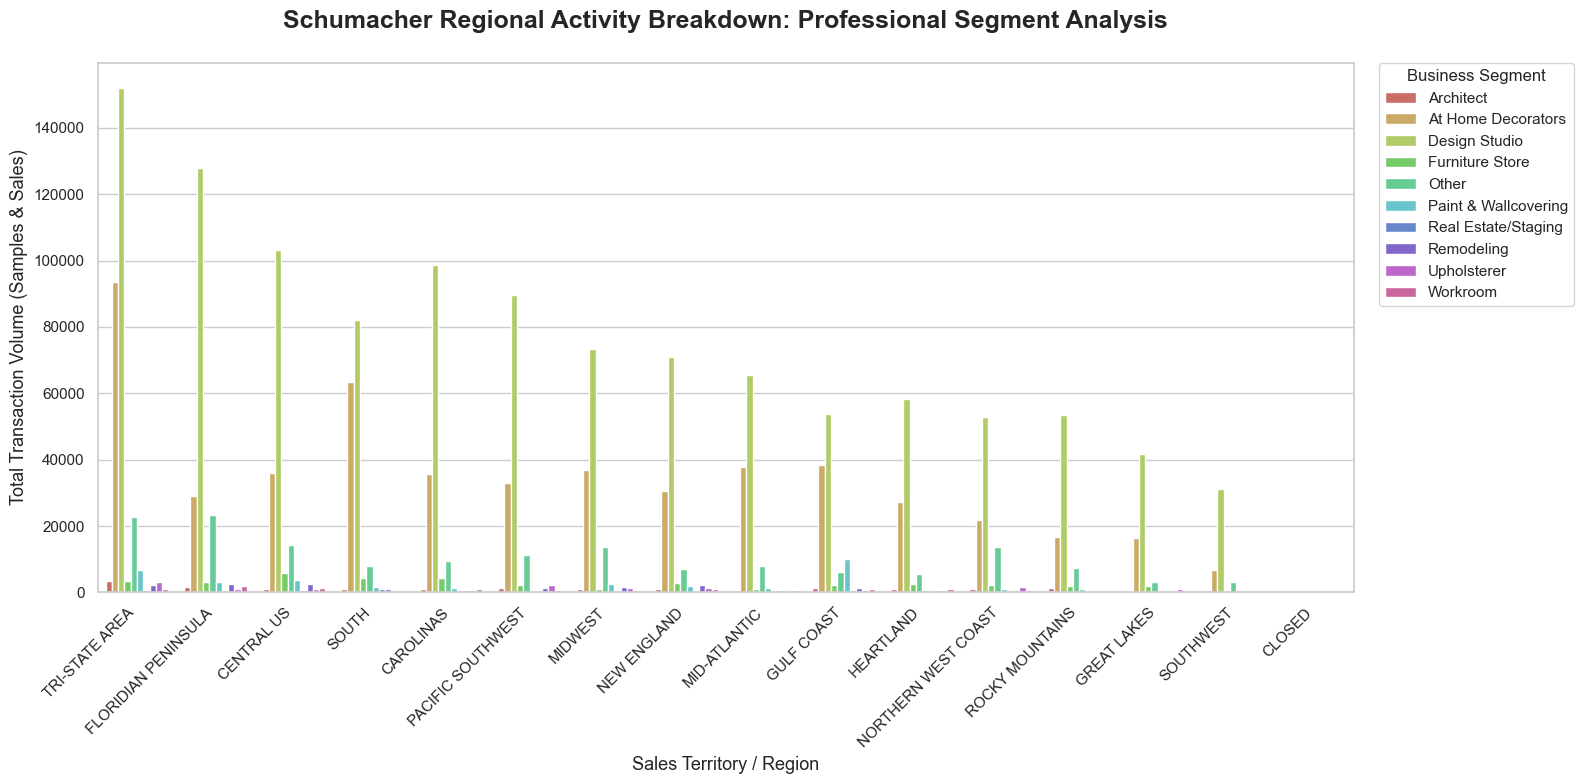

In [27]:
biz_region_split = df_master.groupby(['region', 'business_type']).size().reset_index(name='Activity_Count')
# Sort by total activity per region for better visual hierarchy
region_order = biz_region_split.groupby('region')['Activity_Count'].sum().sort_values(ascending=False).index

plt.figure(figsize=(16, 8))

# Use 'hls' palette for a professional rainbow/multi-color effect
sns.set_style("whitegrid")
ax = sns.barplot(
    x='region', 
    y='Activity_Count', 
    hue='business_type', 
    data=biz_region_split, 
    order=region_order,
    palette=sns.color_palette("hls", len(biz_region_split['business_type'].unique()))
)

plt.title('Schumacher Regional Activity Breakdown: Professional Segment Analysis', fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Total Transaction Volume (Samples & Sales)', fontsize=13)
plt.xlabel('Sales Territory / Region', fontsize=13)

# Perfecting x-axis alignment for professional clarity
plt.xticks(rotation=45, ha='right', fontsize=11)

# Position legend professionally to avoid visual clutter
plt.legend(title='Business Segment', title_fontsize='12', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()